In [15]:
import pandas as pd
import cv2

video_path = '/home/lorenzo/data/Videos/2023/Helgaset/Succisa/HE03_02_1.mp4'

df_old = pd.read_csv('old.csv')
# print(df_old)
video_df = df_old[df_old['video_path'] == video_path]
print(video_df)


cap = cv2.VideoCapture(str(video_path))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(total_frames)

cap = cv2.VideoCapture(video_path)
count = 0

while True:
    success, frame = cap.read()
    if not success:
        break
    count += 1

print(f"Actual frames: {count}")
cap.release()

                                               video_path  frame_number  \
919693  /home/lorenzo/data/Videos/2023/Helgaset/Succis...             0   
919694  /home/lorenzo/data/Videos/2023/Helgaset/Succis...             1   
919695  /home/lorenzo/data/Videos/2023/Helgaset/Succis...             2   
919696  /home/lorenzo/data/Videos/2023/Helgaset/Succis...             3   
919697  /home/lorenzo/data/Videos/2023/Helgaset/Succis...             4   
...                                                   ...           ...   
930325  /home/lorenzo/data/Videos/2023/Helgaset/Succis...         10632   
930326  /home/lorenzo/data/Videos/2023/Helgaset/Succis...         10633   
930327  /home/lorenzo/data/Videos/2023/Helgaset/Succis...         10634   
930328  /home/lorenzo/data/Videos/2023/Helgaset/Succis...         10635   
930329  /home/lorenzo/data/Videos/2023/Helgaset/Succis...         10636   

       weather_prediction  confidence  
919693           overcast      0.9964  
919694           ov

In [2]:
import pandas as pd
import os

def load_csv_from_folder(folder_path):
    csv_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    
    df_list = []
    for file in csv_files:
        df = pd.read_csv(file)
        df_list.append(df)
    
    combined_df = pd.concat(df_list, ignore_index=True)
    
    return combined_df

folder_path = '/home/lorenzo/data/Videos'
combined_df = load_csv_from_folder(folder_path)

print(combined_df['weather_prediction'].value_counts())
print("\n")

combined_df.to_csv('combined_weather_predictions.csv', index=False)

print(combined_df.head())

# snow_samples = combined_df[combined_df['weather_prediction'] == 'snow'].sample(5)
# for index, row in snow_samples.iterrows():
#     print(f"Video Path: {row['video_path']}\nFrame Number: {row['frame_number']}\nWeather: {row['weather_prediction']}\n")

# Mean confidence of snow predictions
snow_confidence_mean = combined_df[combined_df['weather_prediction'] == 'snow']['confidence'].mean()
print(f"Mean confidence for snow predictions: {snow_confidence_mean:.4f}")

# Mean confidence of hail predictions
hail_confidence_mean = combined_df[combined_df['weather_prediction'] == 'hail']['confidence'].mean()
print(f"Mean confidence for hail predictions: {hail_confidence_mean:.4f}")

# Mean confidence of overcast predictions
overcast_confidence_mean = combined_df[combined_df['weather_prediction'] == 'overcast']['confidence'].mean()
print(f"Mean confidence for overcast predictions: {overcast_confidence_mean:.4f}")

# Mean confidence of sunshine predictions
sunshine_confidence_mean = combined_df[combined_df['weather_prediction'] == 'sunshine']['confidence'].mean()
print(f"Mean confidence for sunshine predictions: {sunshine_confidence_mean:.4f}")

# video with less frames
min_frames_video = combined_df.groupby('video_path')['frame_number'].max().idxmin()
print(f"Video with the least frames: {min_frames_video}, frames: {combined_df.groupby('video_path')['frame_number'].max().min()}")

weather_prediction
overcast    1145348
sunshine     158949
snow          42760
hail            252
Name: count, dtype: int64


                                          video_path  frame_number  \
0  /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             0   
1  /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             1   
2  /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             2   
3  /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             3   
4  /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             4   

  weather_prediction  confidence  
0               snow      0.9876  
1               snow      0.9746  
2               snow      0.9768  
3               snow      0.9741  
4               snow      0.9728  
Mean confidence for snow predictions: 0.8246
Mean confidence for hail predictions: 0.5781
Mean confidence for overcast predictions: 0.9389
Mean confidence for sunshine predictions: 0.8553
Video with the least frames: /home/lorenzo/data/Videos

In [6]:
# specific_video_df = combined_df[combined_df['video_path'] == '/home/lorenzo/data/Videos/2023/Helgaset/Succisa/HE03_02_1.mp4']
# print(specific_video_df)
print(combined_df)

                                                video_path  frame_number  \
0        /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             0   
1        /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             1   
2        /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             2   
3        /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             3   
4        /home/lorenzo/data/Videos/2023/Helgaset/Trifol...             4   
...                                                    ...           ...   
1347304  /home/lorenzo/data/Videos/2023/Calanda/Scabios...          7898   
1347305  /home/lorenzo/data/Videos/2023/Calanda/Scabios...          7899   
1347306  /home/lorenzo/data/Videos/2023/Calanda/Scabios...          7900   
1347307  /home/lorenzo/data/Videos/2023/Calanda/Scabios...          7901   
1347308  /home/lorenzo/data/Videos/2023/Calanda/Scabios...          7902   

        weather_prediction  confidence  
0                     snow      0.9876  
1    

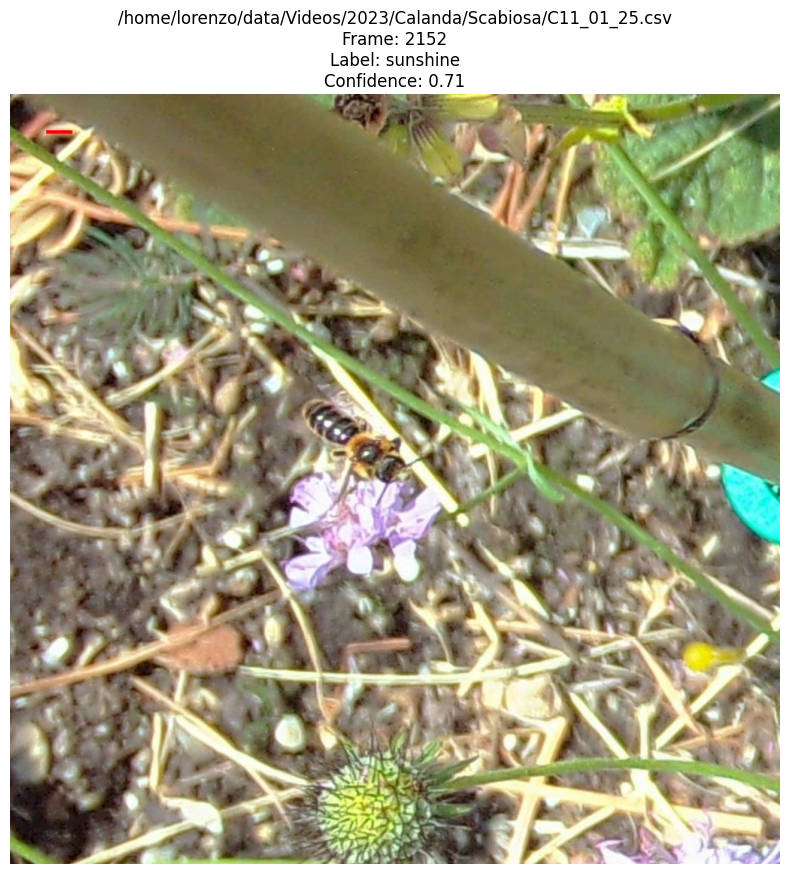

In [399]:
import os
from pathlib import Path
import random
import pandas as pd
import cv2
from matplotlib import pyplot as plt

def load_frame_label(folder, csv_path=None, frame=None):

    csv_files = [str(p) for p in Path(folder).rglob('*.csv')]

    if len(csv_files) == 0:
        print("No csv files found in the folder.")
        return None, None
    
    if csv_path is not None:
        if csv_path in csv_files:
            csv_file = csv_path
            if frame is None:
                df = pd.read_csv(csv_file)
                frame = random.choice(df['frame_number'].unique())
        else:
            return None, None
    else:
        csv_file = random.choice(csv_files)
        df = pd.read_csv(csv_file)
        if frame is None:
            frame = random.choice(df['frame_number'].unique())
        elif frame not in df['frame_number'].values:
            return None, None

    df = pd.read_csv(csv_file)
    row = df[df['frame_number'] == frame].iloc[0]

    video_path = csv_file.replace('.csv', '.mp4')
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame)
    _, image = cap.read()
    cap.release()
    label = row['weather_prediction']
    conf = row['confidence']

    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"{csv_file}\nFrame: {frame}\nLabel: {label}\nConfidence: {conf:.2f}")
    plt.show()

    return image, label

folder = '/home/lorenzo/data/Videos'

# SNOW FRAMES
# image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C04_01_6.csv", frame=5374)
# image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C11_01_25.csv", frame=3027)
# image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C05_01_9.csv", frame=3838)

# image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C14_01_30.csv", frame=1860)
image, label = load_frame_label(folder, csv_path="/home/lorenzo/data/Videos/2023/Calanda/Scabiosa/C11_01_25.csv")#, frame=6472)

if image is None and label is None:
    print("No image and label found.")